In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pingouin as pg

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype']=42
%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif'] 

def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple' ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

%load_ext autoreload
%autoreload 2

import scipy.signal as sg
sns.set_context("poster")
sns.set_style("ticks")

C:\Users\AChub_Lab\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
# Stage 3 Test day files 
filedir=r'U:\Data\snareddu\v1_gamma_inh_of_behav\Stage3'
frrwdfiles=glob.glob(filedir+'\day*\*.csv')
frrwdfiles

['U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_464-et01.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_465-et161.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_467-et315.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_421-et317.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_422-et316.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_476-et0.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 10\\WINDOWS-PJJ0GDK_ke

In [6]:
## CREATING DATAFRAME

dfls=[]
for iii,f in enumerate(frrwdfiles):
    
    if iii%50==0:
        print(f'done loading {iii} out of {len(frrwdfiles)}')
    day_thresh=1
    if day_thresh>0:
        infodf=pd.read_csv(f,names=['Name','Value',''],skiprows=np.arange(17,100000*2,1)) 
        et=f.split('_')[-1].split('.')[0].split('-')[-1][-4:]
        idn=f.split('oneatatimevideo_')[-1].split('-')[-1][:-4]
        day=1

        try:
            tmpdf=pd.read_csv(f,skiprows=17)
            if 'Evnt_Time' not in tmpdf.columns:
                tmpdf=pd.read_csv(f,skiprows=17,header=1)
        except:
            print(f,'not read')

        startcorr=tmpdf[(tmpdf.Group_ID==2)
                     &(tmpdf.Item_Name.str.contains('correction'))
                     ].Evnt_Time.values
        if 'test' in f:
            laseron6t=tmpdf[(tmpdf.Group_ID==4)
                          &(tmpdf.Item_Name=='Laser #2') 
                          ].Evnt_Time.values
            laseron30t=tmpdf[(tmpdf.Group_ID==4)
                          &(tmpdf.Item_Name=='Laser #1') 
                          ].Evnt_Time.values
            laseron1t=tmpdf[(tmpdf.Group_ID==4)
                          &(tmpdf.Item_Name=='Laser #3') 
                          ].Evnt_Time.values
        dispmov1t=tmpdf[(tmpdf.Group_ID==3)
                       &(tmpdf.Evnt_Name.str.contains('Play Video'))
                       &(tmpdf.Arg2_Name=='Video 1')  
                       ].Evnt_Time.values
        dispmov2t=tmpdf[(tmpdf.Group_ID==3)
                        &(tmpdf.Evnt_Name.str.contains('Play Video'))
                        &(tmpdf.Arg2_Name=='Video 2')  
                       ].Evnt_Time.values
        
        

        # response to the GO stim
        mov1cortoucht=tmpdf[(tmpdf.Group_ID==5)
                            &(tmpdf.Item_Name=='loccorrecttouch')
                           ].Evnt_Time.values
        mov1notoucht=tmpdf[(tmpdf.Group_ID==5)
                            &(tmpdf.Item_Name=='notouch')
                           ].Evnt_Time.values
        
        # response to the NO-GO stim
        mov2notoucht=tmpdf[(tmpdf.Group_ID==5)
                        &(tmpdf.Item_Name=='corrnotouch')
                       ].Evnt_Time.values
        mov2inctoucht=tmpdf[(tmpdf.Group_ID==5)
                        &(tmpdf.Item_Name=='locinctouch')
                       ].Evnt_Time.values
        
        trayentryt=tmpdf[(tmpdf.Group_ID==12)
                         &(tmpdf.Evnt_Name.str.contains('On Event'))
                        ].Evnt_Time.values

        onesessionls=[]
        stim_time_ls=[]
        tr_ls=[]
        alldispt=sorted(np.hstack([dispmov1t,dispmov2t]))
        alldispstim=[(i in dispmov1t) for i in alldispt]
        alldispt.append(tmpdf.Evnt_Time.max())
        tr=0
        tr2=0
        tr3=0
        for i,t0 in enumerate(alldispt[:-1]):
            laseron6=laseron6t[abs(laseron6t-t0)<5+0.5]
            laseron30=laseron30t[abs(laseron30t-t0)<5+0.5]
            laseron1=laseron1t[abs(laseron1t-t0)<5+0.5]
            
            if len(laseron6):
                optono=6
            elif len(laseron30):
                optono=30
            elif len(laseron1):
                optono=1
            else:
                optono=0
            
            CorrT=0
            t0,t1=alldispt[i],alldispt[i+1]
            if t0 in dispmov1t:
                stim=1
                tr=tr+1
                tr_ls.append(tr)
            elif t0 in dispmov2t:
                stim=2
                tr2=tr2+1
                tr_ls.append(tr2)
            else:
                stim=3
                tr3=tr3+1
                tr_ls.append(tr3)
            
            if stim==1:

                t_movtoucht=mov1cortoucht[(mov1cortoucht>t0)&(mov1cortoucht<t1)] 
                t_movnotoucht=mov1notoucht[(mov1notoucht>t0)&(mov1notoucht<t1)]
                t_trayentryt=trayentryt[(trayentryt>t0)&(trayentryt<t1)]
                if t_movnotoucht.shape[0]:
                    CorrT=1
                
            elif stim==2:
                t_movnotoucht=mov2notoucht[(mov2notoucht>t0)&(mov2notoucht<t1)]
                t_movtoucht=mov2inctoucht[(mov2inctoucht>t0)&(mov2inctoucht<t1)]
        
                if t_movtoucht.shape[0]:  
                    CorrT=1

                
            if i>=1:
                start_corr_t=startcorr[(startcorr<t0)&(startcorr>alldispt[i-1])]
                
            if t_movtoucht.shape[0]:
                disp2touch=min(np.hstack([t_movtoucht])-t0)

                if stim==1 and len(t_trayentryt):
                    touch2entry=min(t_trayentryt-t_movtoucht)
                else:
                    touch2entry=np.nan
            else:
                disp2touch=np.nan
                touch2entry=np.nan
                
            if t_movnotoucht.shape[0]:
                disp2touch=np.nan
                touch2entry=np.nan
     
            onesessionls.append((i,t0,stim,disp2touch,touch2entry,optono,CorrT))
            stim_time_ls.append(t0)

        x=np.array(stim_time_ls[1:])-np.array(stim_time_ls[:-1])
        iti = np.concatenate([x,np.array([0])])

        onesessiondf=pd.DataFrame(onesessionls,columns=['trial','stim_time','stim','disp2touch','touch2entry',
                                                        'laser',
                                                        'CorrT'])
        onesessiondf['stim_time']=onesessiondf['stim_time']-onesessiondf.stim_time.values[0]
        onesessiondf['et']=et
        onesessiondf['day']=day
        onesessiondf['idn']=idn
        onesessiondf['iti']=iti
        onesessiondf['tr_uq']=tr_ls
        dfls.append(onesessiondf)
allsessiondf=pd.concat(dfls)
allsessiondf['uid']=allsessiondf['idn']+'_'+allsessiondf['trial'].astype(str)
allsessiondf.head(10)

done loading 0 out of 178


NameError: name 'laseron6t' is not defined

In [20]:
allsessiondf.stim.unique()

array([1, 2], dtype=int64)

In [23]:
allsessiondf['new_id'] = -1
tmp_ls=[]
for s,ss in allsessiondf.groupby(['stim','laser','et']):
    i = 1
    for j in range(len(ss['new_id'])):
        ss['new_id'].iloc[j] = i
        i = i+1
    tmp_ls.append(ss)
tmp_df=pd.concat(tmp_ls,ignore_index=True)
tmp_df.head(10)

<ipython-input-23-6173edc44f46>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss['new_id'].iloc[j] = i


,trial,stim_time,stim,disp2touch,touch2entry,laser,CorrT,et,day,idn,iti,tr_uq,uid,new_id
0,0,0.000,1,NaN,NaN,0,1,et0,1,et0,9.945,1,et0_0,1
1,1,9.945,1,NaN,NaN,0,1,et0,1,et0,9.997,2,et0_1,2
2,3,29.979,1,NaN,NaN,0,1,et0,1,et0,9.960,3,et0_3,3
3,5,49.992,1,NaN,NaN,0,1,et0,1,et0,9.957,4,et0_5,4
4,8,79.997,1,NaN,NaN,0,1,et0,1,et0,9.950,5,et0_8,5
5,10,99.995,1,1.001,1.442,0,0,et0,1,et0,15.814,6,et0_10,6
6,11,115.809,1,NaN,NaN,0,1,et0,1,et0,9.944,7,et0_11,7
7,12,125.753,1,NaN,NaN,0,1,et0,1,et0,9.994,8,et0_12,8
8,14,145.814,1,3.210,12.326,0,0,et0,1,et0,29.401,9,et0_14,9
9,16,185.246,1,2.271,2.283,0,0,et0,1,et0,14.022,10,et0_16,10


In [25]:
tmp_foo=tmp_df[tmp_df.new_id<71]  ### Using 70 trials
perc_correct=tmp_foo[(tmp_foo.stim.isin([1,2,3]))
                         ].groupby(['et','stim','laser','day']
                                  ).apply(lambda x:x[(x.CorrT==0)&(x.trial.isin(x.trial.unique()[:]))
                                                    ].disp2touch.shape[0]/x[x.trial.isin(x.trial.unique()[:])
                                                                          ].disp2touch.shape[0]
                                             ).to_frame('perc_correct').reset_index()


### adding perc_touches to df
ls1=[]
for a,b, in perc_correct.groupby(['et','stim','laser','day']):

    if a[1]==2:
        ls=b.apply(lambda x:1-x.perc_correct,axis=1)
        ls1.append(ls)
    else:
        ls=b.apply(lambda x:x.perc_correct,axis=1)
        ls1.append(ls)        
            
ls_ar=np.array(ls1)
perc_correct['perc_tch']=ls_ar

perc_correct

,et,stim,laser,day,perc_correct,perc_tch
0,et0,1,0,1,0.371429,0.371429
1,et0,1,1,1,0.142857,0.142857
2,et0,1,6,1,0.119048,0.119048
3,et0,1,30,1,0.139535,0.139535
4,et0,2,0,1,0.900000,0.100000
5,et0,2,1,1,0.885714,0.114286
6,et0,2,6,1,0.837838,0.162162
7,et0,2,30,1,0.857143,0.142857
8,et01,1,0,1,0.228571,0.228571
9,et01,1,1,1,0.027778,0.027778


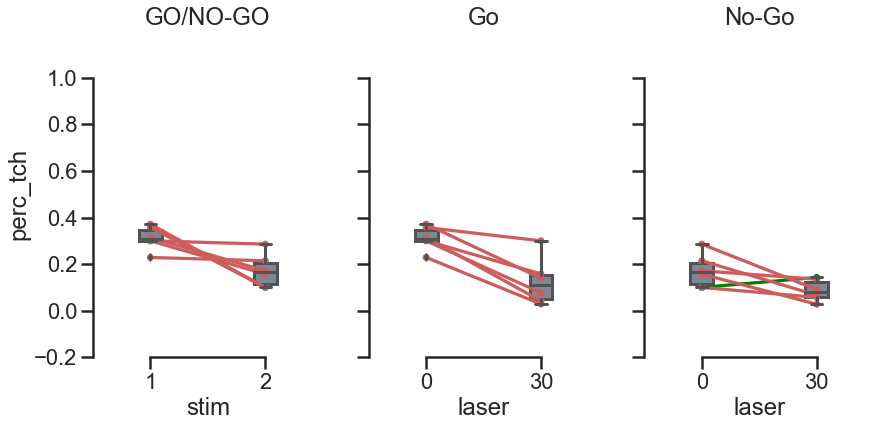

In [27]:
report_directory=r'U:\Data\snareddu\v1_gamma_inh_of_behav\Report/'
tmp1=perc_correct

fig,ax=plt.subplots(1,3,sharey=True,figsize=(14,6))

pg.plot_paired(tmp1[(tmp1.laser==0)]
                  , dv='perc_tch', within='stim', subject='et',ax=ax[0])


pg.plot_paired(tmp1[(tmp1.stim==1)&(tmp1.laser!=1)&(tmp1.laser!=6)&(~tmp1.laser.isna())
                   ]
                  , dv='perc_tch', within='laser', subject='et',ax=ax[1])

pg.plot_paired(tmp1[(tmp1.stim==2)&(tmp1.laser!=1)&(tmp1.laser!=6)&(~tmp1.laser.isna())
                   ]
                  , dv='perc_tch', within='laser', subject='et',ax=ax[2])


ax[0].set_ylim(-0.2,1.2)

ax[1].set_yticks(np.arange(-0.2,1.2,0.2))

ax[1].set_ylim(-0.2,1.2)
ax[0].set_ylim(-0.2,1.2)
ax[2].set_ylim(-0.2,1.2)

ax[0].set_title('GO/NO-GO')
ax[1].set_title('Go')
ax[2].set_title('No-Go')


sns.despine(trim=True, ax=ax[0])
sns.despine(trim=True, ax=ax[1])
sns.despine(trim=True, ax=ax[2])
# plt.savefig(report_directory + '_30Hz.pdf',bbox_inches='tight')
# plt.savefig(report_directory + '_30Hz.png',bbox_inches='tight')

In [12]:
scipy.stats.wilcoxon(tmp1[(tmp1.stim==1)&(tmp1.laser==0)].perc_tch.values, 
                     tmp1[(tmp1.stim==2)&(tmp1.laser==0)].perc_tch.values, zero_method='wilcox', 
                     correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate',
                     keepdims=False)

WilcoxonResult(statistic=0.0, pvalue=0.03125)

In [10]:
scipy.stats.wilcoxon(tmp1[(tmp1.stim==1)&(tmp1.laser==0)].perc_tch.values, 
                     tmp1[(tmp1.stim==1)&(tmp1.laser==30)].perc_tch.values, zero_method='wilcox', 
                     correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate',
                     keepdims=False)

WilcoxonResult(statistic=0.0, pvalue=0.03125)

In [28]:
scipy.stats.wilcoxon(tmp1[(tmp1.stim==2)&(tmp1.laser==0)].perc_tch.values, 
                     tmp1[(tmp1.stim==2)&(tmp1.laser==30)].perc_tch.values, zero_method='wilcox', 
                     correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate',
                     keepdims=False)

WilcoxonResult(statistic=3.0, pvalue=0.15625)